In [72]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from skimage.segmentation import slic
from skimage.measure import regionprops
from skimage.feature import graycomatrix, graycoprops
import sys

BASE_PATH = Path(r'C:\Users\u_fabcore\Downloads\proyecto_eutrofizacion')  # ← ajusta esto

sys.path.insert(0, str(BASE_PATH / 'src'))

from water_masc1 import segmentar_agua, calcular_metricas, visualizar_mascara_final
from water_masc2 import conectar_graffiti_y_cerrar, suavizar_bordes_contorno

# Parámetros de segmentación ya calibrados
PARAMETROS = {
    'a_min': -120,
    'a_max': 1,
    'b_min': -120,
    'b_max': 14,
    'l_min': 50,
    'l_max': 255,
    'h_min': 1,
    'h_max': 180,
    's_min': 0,
    's_max': 110,
}

In [73]:
def seleccionar_imagenes(df, anio, n_imagenes=None, salto=1):
    """
    Selecciona imágenes de un año específico.
    
    Parámetros:
    -----------
    df : DataFrame
        Índice de imágenes
    anio : int
        Año a filtrar
    n_imagenes : int (opcional)
        Número de imágenes a seleccionar
        - Si es None: toma todas las imágenes con el salto especificado
    salto : int
        Cada cuántas imágenes tomar (1=todas, 4=cada 4ta, etc)
        - salto=1: imagen 1, 2, 3, 4, 5...
        - salto=4: imagen 1, 5, 9, 13, 17...
    
    Retorna:
    --------
    DataFrame : imágenes seleccionadas
    """
    
    df_anio = df[df['group'].astype(str) == str(anio)].copy()
    df_anio = df_anio.reset_index(drop=True)
    
    # Selecciona cada salto-ésima imagen
    indices = range(0, len(df_anio), salto)
    df_con_salto = df_anio.iloc[list(indices)].reset_index(drop=True)
    
    # Si se especifica n_imagenes, toma solo las primeras
    if n_imagenes is not None:
        df_seleccion = df_con_salto.head(n_imagenes).reset_index(drop=True)
    else:
        df_seleccion = df_con_salto.reset_index(drop=True)
    
    print(f"Año {anio} — {len(df_anio)} imágenes disponibles")
    print(f"Salto: cada {salto} imágena")
    print(f"Seleccionadas: {len(df_seleccion)}")
    print(f"Índices originales: {list(df_seleccion.index[:10])}{'...' if len(df_seleccion) > 10 else ''}")
    
    return df_seleccion


# === PARÁMETROS A ELEGIR ===
ANIO_ELEGIDO = 2020
N_IMAGENES = 10000          # ← None = toma todas con el salto; o especifica un número (ej: 20)
SALTO = 3                  # ← 1=todas, 4=cada 4ta, 2=cada 2da, etc

df_river = pd.read_csv(BASE_PATH / 'data/metadata/river_water_index.csv')
df_seleccion = seleccionar_imagenes(
    df_river, 
    anio=ANIO_ELEGIDO, 
    n_imagenes=N_IMAGENES,
    salto=SALTO
)

df_seleccion.head()

Año 2020 — 1981 imágenes disponibles
Salto: cada 3 imágena
Seleccionadas: 661
Índices originales: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...


,filepath,source,group,has_gps,site,segmentation_mask_path,mask_type,mask_format
0,data/raw/external/river_water_dataset\2020\ima...,river_water_dataset,2020,True,basento_river,data/raw/external/river_water_dataset\2020\lab...,water_polygon_labelimg,polygon
1,data/raw/external/river_water_dataset\2020\ima...,river_water_dataset,2020,True,basento_river,data/raw/external/river_water_dataset\2020\lab...,water_polygon_labelimg,polygon
2,data/raw/external/river_water_dataset\2020\ima...,river_water_dataset,2020,True,basento_river,data/raw/external/river_water_dataset\2020\lab...,water_polygon_labelimg,polygon
3,data/raw/external/river_water_dataset\2020\ima...,river_water_dataset,2020,True,basento_river,data/raw/external/river_water_dataset\2020\lab...,water_polygon_labelimg,polygon
4,data/raw/external/river_water_dataset\2020\ima...,river_water_dataset,2020,True,basento_river,data/raw/external/river_water_dataset\2020\lab...,water_polygon_labelimg,polygon


In [74]:
from water_masc1 import cargar_mascara_desde_labeling

def extraer_caracteristicas_superpixeles(imagen, mascara_agua, n_segments=20):
    """
    Divide la región de agua en superpíxeles (SLIC) y calcula características
    de color y textura para cada uno.
    
    Parámetros:
    -----------
    imagen : np.ndarray (BGR)
    mascara_agua : np.ndarray (255=agua, 0=no-agua)
    n_segments : int
        Número aproximado de superpíxeles a generar sobre TODA la imagen
        (los que caigan fuera del agua se descartan después)
    
    Retorna:
    --------
    list[dict] : una fila por superpíxel con sus características
    """

    downscale = 4

    # Erosiona la máscara para eliminar bordes ANTES de SLIC
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mascara_agua = cv2.erode(mascara_agua, kernel, iterations=1)

    if downscale > 1:
        h, w = imagen.shape[:2]
        imagen = cv2.resize(imagen, (w//downscale, h//downscale))
        mascara_agua = cv2.resize(mascara_agua, (w//downscale, h//downscale))
    else:
        imagen = imagen
        mascara_agua = mascara_agua
        
    
    img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(imagen, cv2.COLOR_BGR2Lab)
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # SLIC sobre la imagen completa (RGB), luego filtramos por máscara de agua
    segments = slic(
        img_rgb,
        n_segments=n_segments,
        compactness=10,
        sigma=1,
        mask=(mascara_agua > 0)   # SLIC solo genera superpíxeles dentro del agua
    )
    
    filas = []
    
    for label in np.unique(segments):
        if label == 0:
            continue  # 0 = fondo (fuera de la máscara)
        
        region_mask = (segments == label)
        area = region_mask.sum()
        
        if area < 10000:  # descarta superpíxeles minúsculos (ruido de borde)
            continue
        
        # --- Color promedio y variabilidad ---
        h_vals = hsv[:,:,0][region_mask]
        s_vals = hsv[:,:,1][region_mask]
        v_vals = hsv[:,:,2][region_mask]
        l_vals = lab[:,:,0][region_mask]
        a_vals = lab[:,:,1][region_mask].astype(np.float32) - 128
        b_vals = lab[:,:,2][region_mask].astype(np.float32) - 128
        
        # --- Textura simple (desviación estándar de gris = proxy de turbidez/rugosidad) ---
        gray_vals = gray[region_mask]
        textura_std = gray_vals.std()
        
        # --- Centroide (para ubicar la anomalía después en la imagen) ---
        ys, xs = np.where(region_mask)
        centroid_x = xs.mean()
        centroid_y = ys.mean()
        
        filas.append({
            'h_mean': h_vals.mean(), 'h_std': h_vals.std(),
            's_mean': s_vals.mean(), 's_std': s_vals.std(),
            'v_mean': v_vals.mean(), 'v_std': v_vals.std(),
            'l_mean': l_vals.mean(),
            'a_mean': a_vals.mean(),
            'b_mean': b_vals.mean(),
            'textura_std': textura_std,
            'area_px': int(area),
            'centroid_x': float(centroid_x),
            'centroid_y': float(centroid_y),
            'superpixel_label': int(label),
        })
    
    return filas


def construir_tabla_superpixeles(df_seleccion, base_path, parametros, n_segments=250):
    """
    - Segmenta agua en cada imagen
    - Extrae superpíxeles y características
    - Etiqueta cada superpíxel con su foto de origen
    - Devuelve una sola tabla con todo
    """

    todas_las_filas = []
    errores = []

    for idx, row in df_seleccion.iterrows():
        
        ruta_imagen = Path(base_path) / row['filepath']
        nombre_foto = Path(row['filepath']).name
        
        print(f"[{idx+1}/{len(df_seleccion)}] Procesando {nombre_foto}...")
        
        imagen = cv2.imread(str(ruta_imagen))
        if imagen is None:
            errores.append(nombre_foto)
            continue

        # --- Segmentación ---
        mascara_pred = segmentar_agua(imagen, **parametros, downscale=4, verbose=False)
        mascara_final = conectar_graffiti_y_cerrar(mascara_pred, skeleton_kernel=3, dilation_kernel=30)
        mascara_final = suavizar_bordes_contorno(mascara_final, contour_approx=7)

        kernel_size = 15
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        mascara_final = cv2.erode(mascara_final, kernel, iterations=2)

        # Cargar máscara desde labels_segmentation
        #ruta_mascara = Path(base_path) / row['segmentation_mask_path']
        #alto, ancho = imagen.shape[:2]
        #mascara_final = cargar_mascara_desde_labeling(str(ruta_mascara), alto, ancho)
        
        if (mascara_final > 0).sum() < 500:
            print(f"  ⚠ Máscara de agua muy pequeña o vacía, se omite")
            continue
        
        # --- Superpíxeles + características (Etapas 2-3) ---
        filas_imagen = extraer_caracteristicas_superpixeles(
            imagen, mascara_final, n_segments=n_segments
        )

        # --- Etiqueta cada fila con su foto de origen (PASO 3) ---
        for fila in filas_imagen:
            fila['foto_origen'] = nombre_foto
            fila['anio'] = row['group']
        
        todas_las_filas.extend(filas_imagen)
        print(f"  ✓ {len(filas_imagen)} superpíxeles extraídos")

    df_tabla = pd.DataFrame(todas_las_filas)

    # ID único de superpíxel dentro de la tabla completa
    df_tabla.insert(0, 'superpixel_id', range(1, len(df_tabla) + 1))

    print(f"\n{'='*60}")
    print(f"Tabla final: {len(df_tabla)} superpíxeles de {df_seleccion.shape[0] - len(errores)} imágenes")
    if errores:
        print(f"Imágenes con error: {errores}")
    print(f"{'='*60}")

    return df_tabla

DJI_3921.JPG


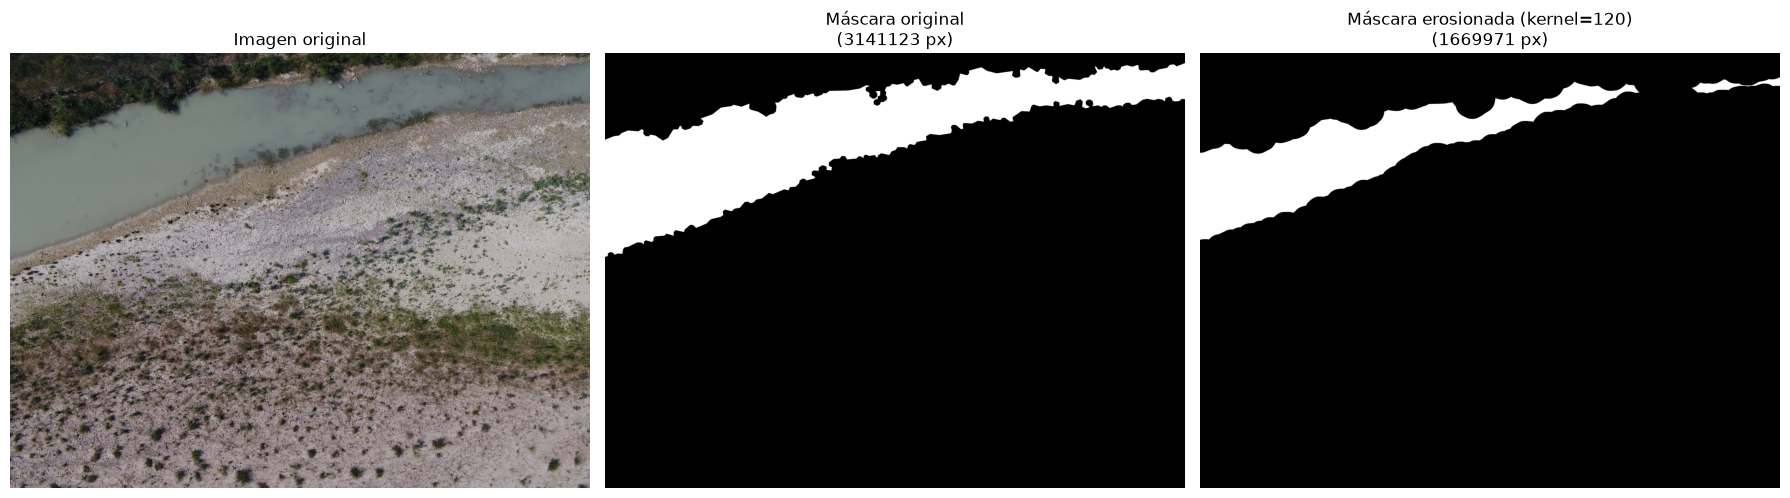

Píxeles eliminados: 1471152


In [75]:
import matplotlib.pyplot as plt

def visualizar_mascara_erosionada(imagen, mascara_original, kernel_size=15):
    """
    Compara la máscara original vs la erosionada (la que usa SLIC).
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mascara_erosionada = cv2.erode(mascara_original, kernel, iterations=2)
    
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(imagen_rgb)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    
    axes[1].imshow(mascara_original, cmap='gray')
    axes[1].set_title(f'Máscara original\n({(mascara_original>0).sum()} px)')
    axes[1].axis('off')
    
    axes[2].imshow(mascara_erosionada, cmap='gray')
    axes[2].set_title(f'Máscara erosionada (kernel={kernel_size})\n({(mascara_erosionada>0).sum()} px)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Píxeles eliminados: {(mascara_original>0).sum() - (mascara_erosionada>0).sum()}")


# === USO ===
# Toma la primera imagen de tu selección
row = df_seleccion.iloc[49]
ruta_imagen = BASE_PATH / row['filepath']

imagen = cv2.imread(str(ruta_imagen))
mascara_pred = segmentar_agua(imagen, **PARAMETROS, downscale=4, verbose=False)
mascara_final = conectar_graffiti_y_cerrar(mascara_pred, skeleton_kernel=3, dilation_kernel=30)
mascara_final = suavizar_bordes_contorno(mascara_final, contour_approx=7)

ruta_imagen = Path(BASE_PATH) / row['filepath']
nombre_foto = Path(row['filepath']).name

print(nombre_foto)
visualizar_mascara_erosionada(imagen, mascara_final, kernel_size=120)

In [76]:
# Ejecuta el pipeline
import matplotlib.pyplot as plt

df_superpixeles = construir_tabla_superpixeles(
    df_seleccion,
    base_path=BASE_PATH,
    parametros=PARAMETROS,
    n_segments=20
)

df_superpixeles.head(10)

[1/661] Procesando DJI_3603.JPG...
  ✓ 0 superpíxeles extraídos
[2/661] Procesando DJI_3606.JPG...
  ✓ 0 superpíxeles extraídos
[3/661] Procesando DJI_3609.JPG...
  ✓ 0 superpíxeles extraídos
[4/661] Procesando DJI_3612.JPG...
  ✓ 0 superpíxeles extraídos
[5/661] Procesando DJI_3615.JPG...
  ✓ 0 superpíxeles extraídos
[6/661] Procesando DJI_3618.JPG...
  ✓ 0 superpíxeles extraídos
[7/661] Procesando DJI_3621.JPG...
  ✓ 0 superpíxeles extraídos
[8/661] Procesando DJI_3624.JPG...
  ✓ 0 superpíxeles extraídos
[9/661] Procesando DJI_3627.JPG...
  ✓ 2 superpíxeles extraídos
[10/661] Procesando DJI_3630.JPG...
  ✓ 1 superpíxeles extraídos
[11/661] Procesando DJI_3633.JPG...
  ✓ 0 superpíxeles extraídos
[12/661] Procesando DJI_3636.JPG...
  ✓ 0 superpíxeles extraídos
[13/661] Procesando DJI_3639.JPG...
  ✓ 0 superpíxeles extraídos
[14/661] Procesando DJI_3642.JPG...
  ✓ 0 superpíxeles extraídos
[15/661] Procesando DJI_3645.JPG...
  ✓ 0 superpíxeles extraídos
[16/661] Procesando DJI_3648.JPG..

,superpixel_id,h_mean,h_std,s_mean,s_std,v_mean,v_std,l_mean,a_mean,b_mean,textura_std,area_px,centroid_x,centroid_y,superpixel_label,foto_origen,anio
0,1,53.306788,11.610688,8.074737,2.087441,179.572956,6.092177,185.607251,-2.463300,1.971851,5.912460,11226,981.376982,316.186175,2,DJI_3627.JPG,2020
1,2,74.348900,19.428779,20.015442,21.090593,159.558299,34.750423,163.345767,-2.773816,-0.857441,38.596519,13405,1069.489593,610.541664,11,DJI_3627.JPG,2020
2,3,87.071301,11.258160,18.911832,3.998741,159.897947,7.319162,165.091320,-4.001448,-0.950762,7.197968,11739,1256.859784,639.683874,9,DJI_3630.JPG,2020
3,4,78.052632,4.781483,12.583750,2.295329,174.884268,3.036523,180.100077,-3.817614,0.332405,3.289626,10412,42.633116,210.299750,2,DJI_3686.JPG,2020
4,5,69.823251,15.085283,13.356701,3.536333,164.700298,11.065783,170.526461,-3.761010,1.474922,10.764162,13737,790.440926,364.604717,11,DJI_3686.JPG,2020
5,6,80.263716,14.737832,10.940175,2.698108,166.775195,6.068284,172.738327,-2.667121,0.090272,6.365447,10280,703.622665,413.030642,16,DJI_3686.JPG,2020
6,7,90.658960,8.598353,6.891550,2.236208,178.992201,6.887935,184.448573,-1.365446,-0.629691,7.251013,10899,205.644922,53.397101,1,DJI_3692.JPG,2020
7,8,88.849407,9.001694,5.937391,1.426523,179.137663,1.489710,184.962182,-1.320727,-0.486875,1.701538,10286,188.910072,158.102178,4,DJI_3692.JPG,2020
8,9,68.791700,17.848643,6.697858,2.468296,172.086821,6.153218,178.574958,-1.820226,0.538079,6.352769,11253,214.349240,922.035102,20,DJI_3692.JPG,2020
9,10,58.595195,25.004691,3.614944,0.999264,178.259283,1.364506,185.010739,-0.675373,0.480615,1.703817,10988,519.052421,238.994084,3,DJI_3695.JPG,2020


In [83]:
OUTPUT_DIR = BASE_PATH / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

nombre_archivo = f"superpixeles_anio{ANIO_ELEGIDO}_n{N_IMAGENES}_v1.csv"
ruta_salida = OUTPUT_DIR / nombre_archivo

df_superpixeles.to_csv(ruta_salida, index=False)

print(f"✓ Tabla guardada en: {ruta_salida}")
print(f"  Filas: {len(df_superpixeles)}")
print(f"  Columnas: {list(df_superpixeles.columns)}")

✓ Tabla guardada en: C:\Users\u_fabcore\Downloads\proyecto_eutrofizacion\data\processed\superpixeles_anio2020_n10000_v1.csv
  Filas: 1782
  Columnas: ['superpixel_id', 'h_mean', 'h_std', 's_mean', 's_std', 'v_mean', 'v_std', 'l_mean', 'a_mean', 'b_mean', 'textura_std', 'area_px', 'centroid_x', 'centroid_y', 'superpixel_label', 'foto_origen', 'anio', 'anomalia', 'score_anomalia']


# Cargar y trabajar con tabla creada de superpíxeles

In [78]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import seaborn as sns

CARACTERISTICAS_DETECCION = [
    'h_mean', 'h_std',          # Tono y variabilidad
    's_mean', 's_std',          # Saturación y variabilidad
    'v_mean', 'v_std',          # Brillo y variabilidad
    'l_mean',                   # Luminancia Lab
    'a_mean',                   # Eje verde-rojo
    'b_mean',                   # Eje azul-amarillo
    'textura_std',              # Turbidez/rugosidad
]

X = df_superpixeles[CARACTERISTICAS_DETECCION].copy()

print(f"Features para detección: {len(CARACTERISTICAS_DETECCION)}")
print(f"Superpíxeles: {len(X)}")
print(f"\nEstadísticas de features:")
print(X.describe())

Features para detección: 10
Superpíxeles: 1782

Estadísticas de features:
            h_mean        h_std       s_mean        s_std       v_mean  \
count  1782.000000  1782.000000  1782.000000  1782.000000  1782.000000   
mean     55.683441     9.522871    23.797439     6.356412   144.959395   
std      21.479014     5.990650    13.998406     5.266414    25.328112   
min      18.905962     0.745887     3.078687     0.342108    73.656544   
25%      36.901681     5.057056    14.004713     2.439457   128.729121   
50%      54.079624     8.188546    20.757499     4.650314   147.001869   
75%      71.142808    12.569496    32.064754     8.951204   164.583726   
max     105.323755    35.435672    96.883424    46.387834   200.370453   

             v_std       l_mean       a_mean       b_mean  textura_std  
count  1782.000000  1782.000000  1782.000000  1782.000000  1782.000000  
mean      9.059086   150.252524    -3.534958     3.508714     9.138723  
std       7.360173    26.002038     1.85

## Isolation Forest

In [79]:
# Normaliza las características (importante para Isolation Forest)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# Entrena Isolation Forest
# contamination = porcentaje esperado de anomalías (ajusta según necesidad)
iso_forest = IsolationForest(
    contamination=0.01,
    random_state=42,
    n_estimators=100
)

# Predice: -1 = anomalía, 1 = normal
predicciones = iso_forest.fit_predict(X_escalado)

# Score de anomalía: más negativo = más anómalo
scores_anomalia = iso_forest.score_samples(X_escalado)

# Añade los resultados a la tabla
df_superpixeles['anomalia'] = predicciones  # -1 o 1
df_superpixeles['score_anomalia'] = scores_anomalia  # valores negativos = más raro

# Ordena por anomalía (más raro primero)
df_superpixeles_ordenado = df_superpixeles.sort_values('score_anomalia', ascending=True)

print(f"Anomalías detectadas: {(df_superpixeles['anomalia'] == -1).sum()}")
print(f"Normal: {(df_superpixeles['anomalia'] == 1).sum()}")

Anomalías detectadas: 18
Normal: 1764


In [80]:
# TOP 10 superpíxeles más anómalos
print("TOP 10 SUPERPÍXELES MÁS ANÓMALOS:")
print("="*80)

top_anomalas = df_superpixeles_ordenado.head(10)

for idx, row in top_anomalas.iterrows():
    print(f"\nSuperpíxel ID: {row['superpixel_id']}")
    print(f"  Foto origen: {row['foto_origen']}")
    print(f"  Score anomalía: {row['score_anomalia']:.4f}")
    print(f"  Posición en foto: ({row['centroid_x']:.0f}, {row['centroid_y']:.0f})")
    print(f"  Color Lab: L={row['l_mean']:.1f}, a*={row['a_mean']:.1f}, b*={row['b_mean']:.1f}")
    print(f"  Saturación: {row['s_mean']:.1f}")
    print(f"  Textura (turbidez): {row['textura_std']:.2f}")

TOP 10 SUPERPÍXELES MÁS ANÓMALOS:

Superpíxel ID: 1589
  Foto origen: DJI_7235.JPG
  Score anomalía: -0.6903
  Posición en foto: (105, 628)
  Color Lab: L=128.5, a*=-6.0, b*=5.5
  Saturación: 49.0
  Textura (turbidez): 42.91

Superpíxel ID: 1510
  Foto origen: DJI_7199.JPG
  Score anomalía: -0.6871
  Posición en foto: (866, 586)
  Color Lab: L=132.1, a*=-4.3, b*=4.6
  Saturación: 45.3
  Textura (turbidez): 46.03

Superpíxel ID: 581
  Foto origen: DJI_4732.JPG
  Score anomalía: -0.6756
  Posición en foto: (404, 323)
  Color Lab: L=114.7, a*=-2.8, b*=-5.6
  Saturación: 65.6
  Textura (turbidez): 36.32

Superpíxel ID: 1569
  Foto origen: DJI_7232.JPG
  Score anomalía: -0.6722
  Posición en foto: (250, 162)
  Color Lab: L=143.9, a*=-6.0, b*=1.4
  Saturación: 47.7
  Textura (turbidez): 58.76

Superpíxel ID: 606
  Foto origen: DJI_4777.JPG
  Score anomalía: -0.6453
  Posición en foto: (1223, 748)
  Color Lab: L=89.1, a*=-5.0, b*=-2.9
  Saturación: 66.5
  Textura (turbidez): 22.25

Superpíxel

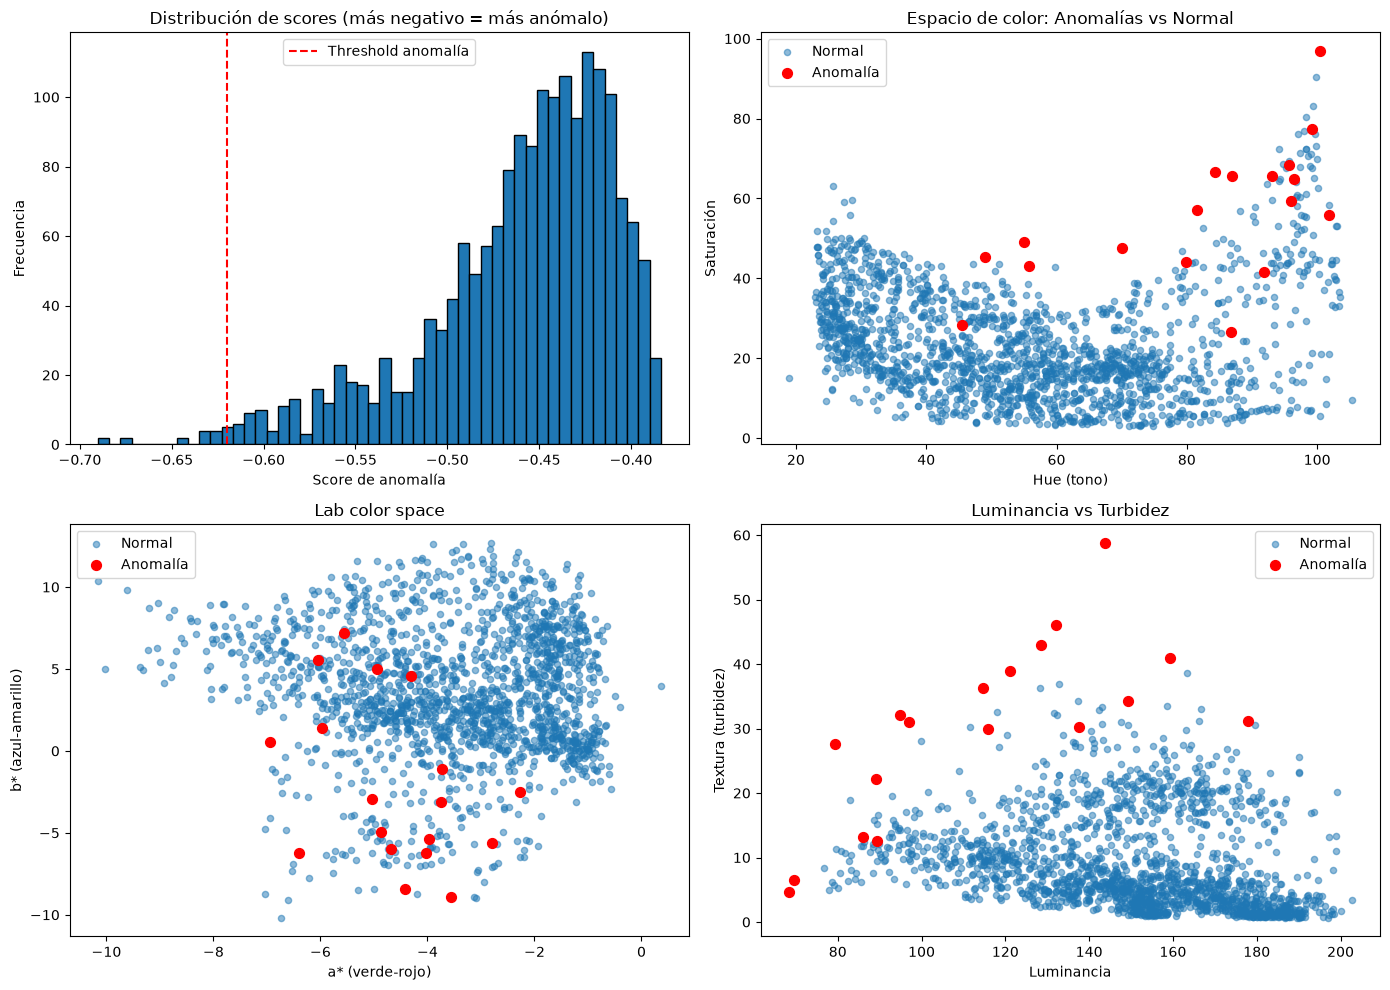

In [81]:
# Gráfico 1: Distribución de scores de anomalía
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score de anomalía
axes[0, 0].hist(df_superpixeles['score_anomalia'], bins=50, edgecolor='black')
axes[0, 0].axvline(df_superpixeles[df_superpixeles['anomalia'] == -1]['score_anomalia'].max(), 
                   color='red', linestyle='--', label='Threshold anomalía')
axes[0, 0].set_xlabel('Score de anomalía')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de scores (más negativo = más anómalo)')
axes[0, 0].legend()

# Saturación: anomalías vs normal
axes[0, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['h_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['s_mean'],
                   alpha=0.5, label='Normal', s=20)
axes[0, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['h_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['s_mean'],
                   color='red', label='Anomalía', s=50)
axes[0, 1].set_xlabel('Hue (tono)')
axes[0, 1].set_ylabel('Saturación')
axes[0, 1].set_title('Espacio de color: Anomalías vs Normal')
axes[0, 1].legend()

# Lab a* vs b*
axes[1, 0].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['a_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['b_mean'],
                   alpha=0.5, label='Normal', s=20)
axes[1, 0].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['a_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['b_mean'],
                   color='red', label='Anomalía', s=50)
axes[1, 0].set_xlabel('a* (verde-rojo)')
axes[1, 0].set_ylabel('b* (azul-amarillo)')
axes[1, 0].set_title('Lab color space')
axes[1, 0].legend()

# Textura vs Luminancia
axes[1, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == 1]['l_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == 1]['textura_std'],
                   alpha=0.5, label='Normal', s=20)
axes[1, 1].scatter(df_superpixeles[df_superpixeles['anomalia'] == -1]['l_mean'],
                   df_superpixeles[df_superpixeles['anomalia'] == -1]['textura_std'],
                   color='red', label='Anomalía', s=50)
axes[1, 1].set_xlabel('Luminancia')
axes[1, 1].set_ylabel('Textura (turbidez)')
axes[1, 1].set_title('Luminancia vs Turbidez')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Visualización

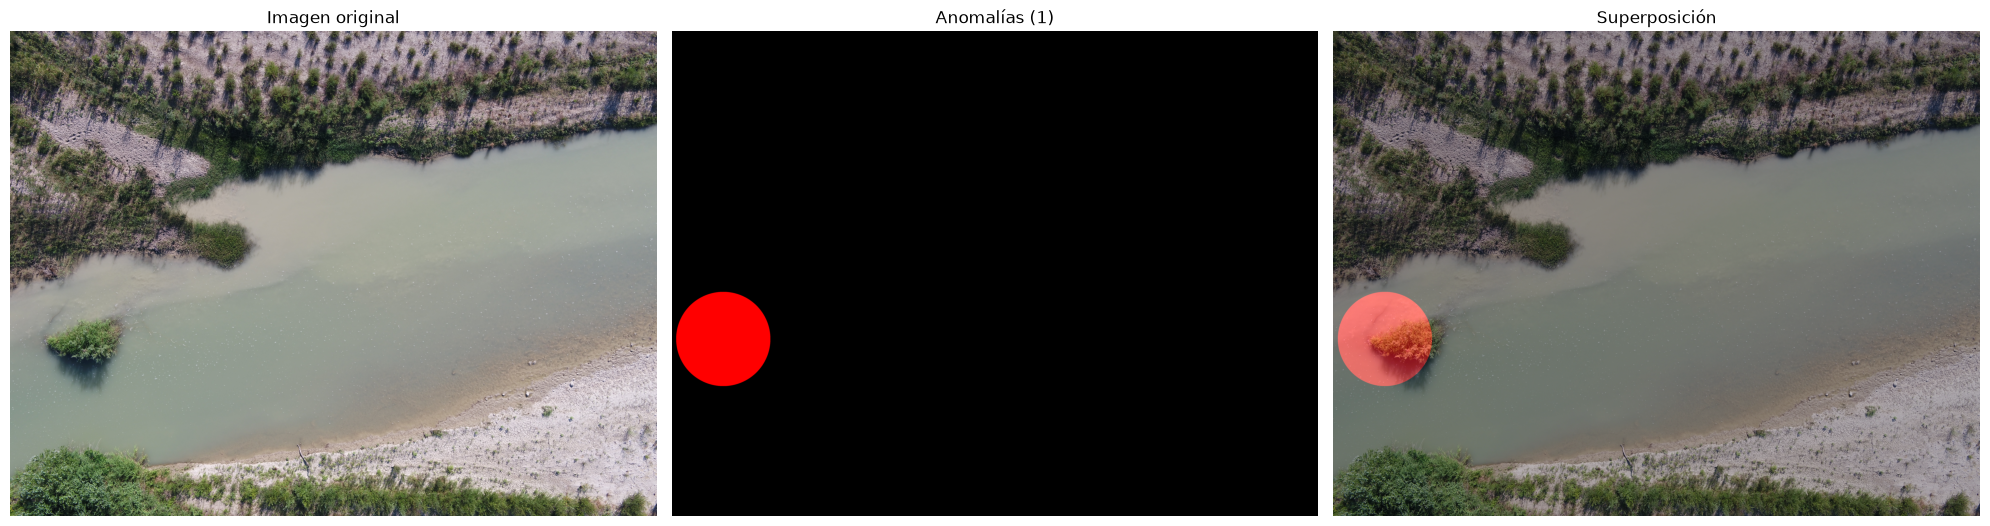


DJI_7235.JPG: 1 anomalías


In [107]:
df_anomalias = df_superpixeles[df_superpixeles['anomalia'] == -1].copy()


def visualizar_anomalias_en_imagen(
    ruta_imagen, 
    df_superpixeles_anomalias,
    foto_origen,
    downscale=2  # ← mismo que usaste en entrenamiento
):
    """
    Visualiza anomalías escalando correctamente los centroides.
    """
    
    imagen = cv2.imread(str(ruta_imagen))
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    h, w = imagen_rgb.shape[:2]
    
    df_imagen = df_superpixeles_anomalias[
        df_superpixeles_anomalias['foto_origen'] == foto_origen
    ]
    
    anomalias = df_imagen[df_imagen['anomalia'] == -1]
    
    if len(anomalias) == 0:
        print(f"Sin anomalías en {foto_origen}")
        return
    
    mascara_anomalias = np.zeros((h, w, 3), dtype=np.uint8)
    
    for idx, row in anomalias.iterrows():
        # Escala los centroides si fueron generados en imagen downscaleada
        centroid_x = int(row['centroid_x'] * downscale)  # ← ESCALA
        centroid_y = int(row['centroid_y'] * downscale)  # ← ESCALA
        
        # Asegúrate que está dentro de imagen
        centroid_x = min(max(centroid_x, 0), w - 1)
        centroid_y = min(max(centroid_y, 0), h - 1)
        
        area = int(row['area_px'] * downscale * downscale)  # ← ESCALA
        radio = max(8, int(np.sqrt(area / np.pi)))
        
        cv2.circle(mascara_anomalias, (centroid_x, centroid_y), radio, (255, 0, 0), -1)
    
    imagen_resultado = cv2.addWeighted(imagen_rgb, 0.75, mascara_anomalias, 0.5, 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    axes[0].imshow(imagen_rgb)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')
    
    axes[1].imshow(mascara_anomalias)
    axes[1].set_title(f'Anomalías ({len(anomalias)})')
    axes[1].axis('off')
    
    axes[2].imshow(imagen_resultado)
    axes[2].set_title('Superposición')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{foto_origen}: {len(anomalias)} anomalías")


# === USO ===
INDICE_FOTO = 13
DOWNSCALE = 4  # ← MISMO que usaste en extraer_caracteristicas_superpixeles

df_index = pd.read_csv(BASE_PATH / 'data' / 'metadata' / 'river_water_index.csv')

foto_a_visualizar = df_anomalias['foto_origen'].unique()[INDICE_FOTO]
row_imagen = df_index[df_index['filepath'].str.contains(foto_a_visualizar)].iloc[0]
ruta_imagen = BASE_PATH / row_imagen['filepath']

visualizar_anomalias_en_imagen(
    ruta_imagen=str(ruta_imagen),
    df_superpixeles_anomalias=df_superpixeles,
    foto_origen=foto_a_visualizar,
    downscale=DOWNSCALE
)

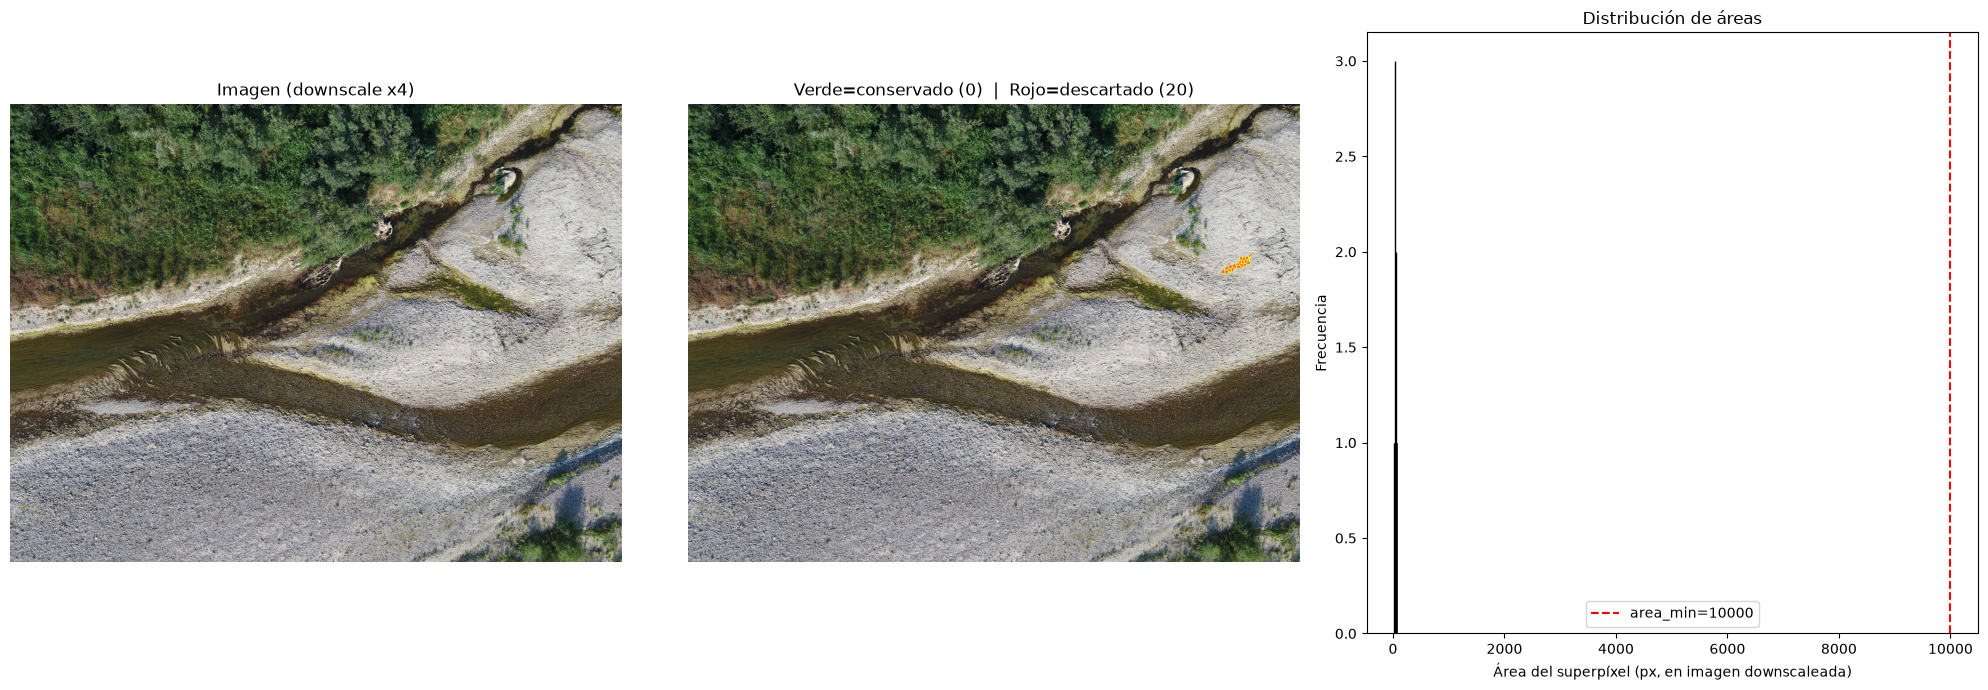

Total superpíxeles generados: 20
Conservados (area >= 10000): 0
Descartados (area < 10000): 20
Área mínima observada: 25 | Área máxima observada: 62


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.segmentation import slic, mark_boundaries

def visualizar_superpixeles_descartados(
    ruta_imagen,
    mascara_agua,
    n_segments=20,
    downscale=4,
    area_min=10000,
    kernel_erosion=15
):
    """
    Reproduce el mismo preprocesamiento de extraer_caracteristicas_superpixeles
    (erosión de máscara + downscale + SLIC) y muestra qué superpíxeles se
    descartan por el filtro de área mínima.

    Parámetros
    ----------
    ruta_imagen : str o Path
    mascara_agua : np.ndarray (255=agua, 0=no-agua), YA en la resolución original
    n_segments, downscale, area_min, kernel_erosion : deben coincidir con los
        que usas en extraer_caracteristicas_superpixeles para que el resultado
        sea representativo.
    """

    imagen = cv2.imread(str(ruta_imagen))

    # --- mismo preprocesamiento que extraer_caracteristicas_superpixeles ---
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_erosion, kernel_erosion))
    mascara_erosionada = cv2.erode(mascara_agua, kernel, iterations=1)

    if downscale > 1:
        h, w = imagen.shape[:2]
        imagen_ds = cv2.resize(imagen, (w // downscale, h // downscale))
        mascara_ds = cv2.resize(mascara_erosionada, (w // downscale, h // downscale))
    else:
        imagen_ds = imagen
        mascara_ds = mascara_erosionada

    img_rgb = cv2.cvtColor(imagen_ds, cv2.COLOR_BGR2RGB)

    segments = slic(
        img_rgb,
        n_segments=n_segments,
        compactness=10,
        sigma=1,
        mask=(mascara_ds > 0)
    )

    # --- clasifica cada superpíxel como conservado / descartado ---
    areas = []
    mapa_estado = np.zeros(segments.shape, dtype=np.uint8)  # 0=fondo, 1=conservado, 2=descartado

    for label in np.unique(segments):
        if label == 0:
            continue
        region_mask = (segments == label)
        area = region_mask.sum()
        areas.append(area)
        
        if area < area_min:
            mapa_estado[region_mask] = 2
        else:
            mapa_estado[region_mask] = 1

    n_conservados = int((np.unique(segments[mapa_estado == 1])).size)
    n_descartados = int((np.unique(segments[mapa_estado == 2])).size)

    # --- overlay: verde = conservado, rojo = descartado ---
    overlay = img_rgb.copy()
    overlay[mapa_estado == 1] = (overlay[mapa_estado == 1] * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
    overlay[mapa_estado == 2] = (overlay[mapa_estado == 2] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)

    overlay_bordes = mark_boundaries(overlay, segments, color=(1, 1, 0))

    # --- figura ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Imagen (downscale x{downscale})')
    axes[0].axis('off')

    axes[1].imshow(overlay_bordes)
    axes[1].set_title(f'Verde=conservado ({n_conservados})  |  Rojo=descartado ({n_descartados})')
    axes[1].axis('off')

    axes[2].hist(areas, bins=40, edgecolor='black')
    axes[2].axvline(area_min, color='red', linestyle='--', label=f'area_min={area_min}')
    axes[2].set_xlabel('Área del superpíxel (px, en imagen downscaleada)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].set_title('Distribución de áreas')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Total superpíxeles generados: {len(areas)}")
    print(f"Conservados (area >= {area_min}): {n_conservados}")
    print(f"Descartados (area < {area_min}): {n_descartados}")
    print(f"Área mínima observada: {min(areas)} | Área máxima observada: {max(areas)}")


# === USO ===
# elige una imagen de tu selección (o cualquier fila del índice)
row = df_seleccion.iloc[310]
ruta_imagen = BASE_PATH / row['filepath']

imagen_full = cv2.imread(str(ruta_imagen))
mascara_pred = segmentar_agua(imagen_full, **PARAMETROS, downscale=4, verbose=False)
mascara_final = conectar_graffiti_y_cerrar(mascara_pred, skeleton_kernel=3, dilation_kernel=30)
mascara_final = suavizar_bordes_contorno(mascara_final, contour_approx=7)

visualizar_superpixeles_descartados(
    ruta_imagen=ruta_imagen,
    mascara_agua=mascara_final,
    n_segments=20,
    downscale=4,      # mismo que usas en extraer_caracteristicas_superpixeles
    area_min=10000,
    kernel_erosion=15
)

## Visualizar N imágenes con anomalías detectadas

In [ ]:
# === USO ===
N_IMAGENES_A_VISUALIZAR = 5   # ← cuántas imágenes con anomalías quieres ver
ORDENAR_POR = 'n_anomalias'   # 'n_anomalias' = imágenes con más anomalías primero
                               # 'score'       = imagen con la anomalía más severa primero

# Una fila por foto: cuántas anomalías tiene y cuál es su score más severo (más negativo)
resumen_anomalias = (
    df_anomalias
    .groupby('foto_origen')
    .agg(n_anomalias=('superpixel_id', 'count'), score_min=('score_anomalia', 'min'))
    .reset_index()
)

if ORDENAR_POR == 'n_anomalias':
    resumen_anomalias = resumen_anomalias.sort_values('n_anomalias', ascending=False)
elif ORDENAR_POR == 'score':
    resumen_anomalias = resumen_anomalias.sort_values('score_min', ascending=True)
else:
    raise ValueError("ORDENAR_POR debe ser 'n_anomalias' o 'score'")

n_a_mostrar = min(N_IMAGENES_A_VISUALIZAR, len(resumen_anomalias))
fotos_a_mostrar = resumen_anomalias['foto_origen'].head(n_a_mostrar).tolist()

print(f"Imágenes con al menos 1 anomalía: {len(resumen_anomalias)}")
print(f"Mostrando las {n_a_mostrar} más relevantes (orden: {ORDENAR_POR})\n")
print(resumen_anomalias.head(n_a_mostrar).to_string(index=False))

df_index = pd.read_csv(BASE_PATH / 'data' / 'metadata' / 'river_water_index.csv')

for foto in fotos_a_mostrar:
    coincidencias = df_index[df_index['filepath'].str.contains(foto)]
    if coincidencias.empty:
        print(f"\n⚠ No se encontró {foto} en el índice, se omite")
        continue

    ruta_imagen = BASE_PATH / coincidencias.iloc[0]['filepath']
    visualizar_anomalias_en_imagen(
        ruta_imagen=str(ruta_imagen),
        df_superpixeles_anomalias=df_superpixeles,
        foto_origen=foto,
        downscale=DOWNSCALE
    )